# Figure S12 - Hb9-RFP reporter

In [1]:
import rushd as rd
import pandas as pd
import numpy as np
import scipy.stats
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
from textwrap import wrap
from statannotations.Annotator import Annotator
#from statannot import add_stat_annotation
import itertools

import warnings
warnings.filterwarnings("ignore",category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)#, module="seaborn._oldcore")

sns.set_theme(style="ticks",font_scale=1)


In [2]:
experimentdir1 = rd.datadir/'data'/'attune'/'Brittany_attune'/'2025.11.10_iMN_flow_stain'
experimentdir2 = rd.datadir/'data'/'attune'/'Brittany_attune'/'2026.07.06_Hb9-Syn_reporters'
outputdir = rd.rootdir/'output'/'Figure_S12'

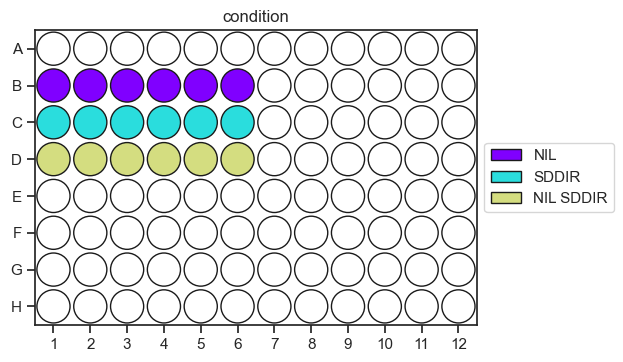

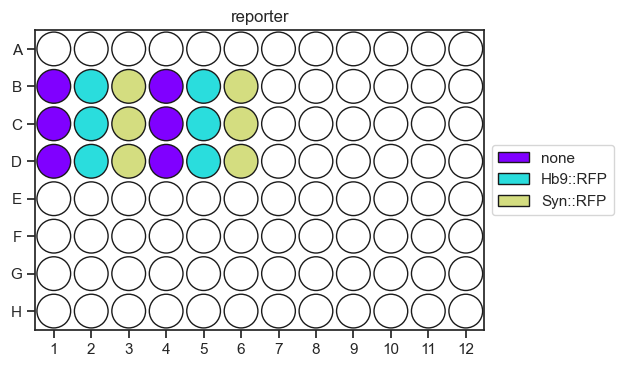

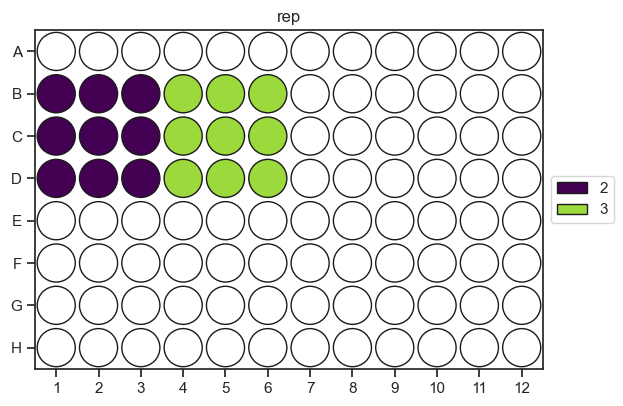

In [3]:
rd.plot.plot_well_metadata(experimentdir2/'metadata.yaml')


# Load Data

In [4]:
data_columns = ['GFP-A','RFP-A']

plates = pd.DataFrame({
        'data_path': [experimentdir1/f'csv']           + [experimentdir2/f'csv'],
        'yaml_path': [experimentdir1/f'metadata2.yaml'] + [experimentdir2/f'metadata.yaml'],
    })
df = rd.flow.load_groups_with_metadata(plates, columns=data_columns)
df['condition2'] = df['condition'] + ' ' + df['reporter']


Get rid of negative values

In [5]:
plot_df = df[df[data_columns].gt(0).all(axis=1)]

RFP Gate

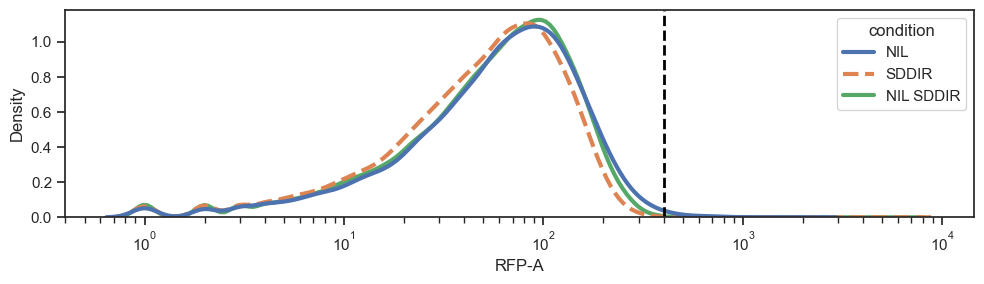

In [6]:
RFP_gate = 400

slice = plot_df[(plot_df.reporter.isin(['none','Hb9::RFP','Syn::RFP']))]
slice = slice[(slice['rep'] == 3) & (slice.reporter == 'none')]

fig, ax = plt.subplots(figsize=(10, 3))

sns.kdeplot(ax=ax,data=slice,x='RFP-A',hue='condition',log_scale=True,common_norm=False,linewidth=3)
plt.axvline(x=RFP_gate,linestyle='--',color='black',linewidth=2)


lss = reversed(['-', '-', '-', '--','--', '-', '-', '--','-'])
handles = ax.legend_.legend_handles[::-1]
for line, ls, handle in zip(ax.lines, lss, handles):
    line.set_linestyle(ls)
    handle.set_ls(ls)

plt.tight_layout()
plt.show()

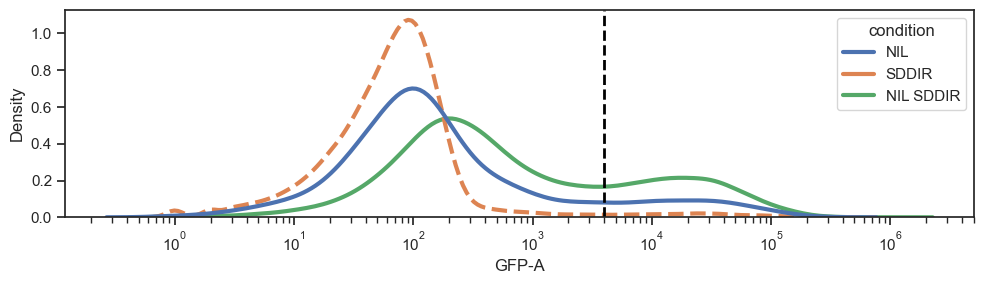

In [7]:
iMN_gate = 4 * 10**3

slice = plot_df[(plot_df.reporter.isin(['none']))]
slice = slice[(slice['rep'] == 1)]

# Plot gate
fig, ax = plt.subplots(figsize=(10, 3))

sns.kdeplot(ax=ax,data=slice,x='GFP-A',hue='condition',log_scale=True,common_norm=False,linewidth=3)
plt.axvline(x=iMN_gate,linestyle='--',color='black',linewidth=2)

lss = reversed(['-', '-', '-', '--','--', '-', '-', '--','-'])

for line, ls, handle in zip(ax.lines, lss, handles):
    line.set_linestyle(ls)
    handle.set_ls(ls)

plt.tight_layout()
plt.show()

In [8]:
# Get rid of SDDIR GFP+ cells that are contamination from NIL SDDIR condition during flow

df = df[~((df['condition'] == 'SDDIR') & (df['GFP-A'] > 400))]
plot_df = df[df[data_columns].gt(0).all(axis=1)]

# Plotting Functions

In [9]:
def jointplot(x,y,data,filename,height=3,hue=None,hue_order=None,
              plottitle='',palette='viridis',type='scatter',x_gate=None,y_gate=None,xlim=(1,5*10**7),ylim=(1,5*10**7)):

    g = sns.JointGrid(data=data, x=x, y=y, hue=hue,ratio=3, hue_order=hue_order,space=0,
                    xlim=xlim,ylim=ylim,height=height)
    
    # plot histograms in marginals
    g = g.plot_marginals(sns.kdeplot, fill=True, alpha=0.1, common_norm=False, log_scale=True, palette=palette)
    ax = g.ax_joint

    if 'scatter' in type:
        g.plot_joint(sns.scatterplot,s=3,hue_order=hue_order,palette=palette) #scatter plot in main graph
    if 'contour' in type:
        g = g.plot_joint(sns.kdeplot, alpha=0.8,palette=palette, common_norm=True,levels=12) #contour plot in main graph 
    if 'filled' in type:
        for cond in hue_order:
            g = g.plot_joint(sns.kdeplot, data=data[data[hue]==cond],alpha=0.5,fill=True,palette=palette) #filled contour plot in main graph 

    # Add in gates (optional)
    if x_gate:
        ax.axvline(x_gate, 0, 1, color='grey',linestyle='--')
    if y_gate:
        ax.axhline(y_gate, 0, 1, color='grey',linestyle='--')

    plt.title(plottitle)
    plt.subplots_adjust(left=0.2, right=0.95, top=0.9, bottom=0.25) # make all plots have the same area

    from matplotlib.patches import Patch

    legend_elements = [
        Patch(facecolor='grey', edgecolor='black', linewidth=1,
            label='SDDIR'),
        Patch(facecolor='darkred', edgecolor='black', linewidth=1,
            label='desNb'),
        Patch(facecolor='coral', edgecolor='black', linewidth=1,
            label='wtNb')
    ]

    ax_scatter.legend(
        handles=legend_elements,
        loc='upper left',
        bbox_to_anchor=(1.02, 1),
        frameon=False,
        handlelength=1.2,
        handleheight=1.2
    )


# Plot Results

In [10]:
savedict = {'Hb9::RFP':'Hb9-RFP', 'Syn::RFP':'Syn-RFP'}

**Figure S12B - HB9-RFP**

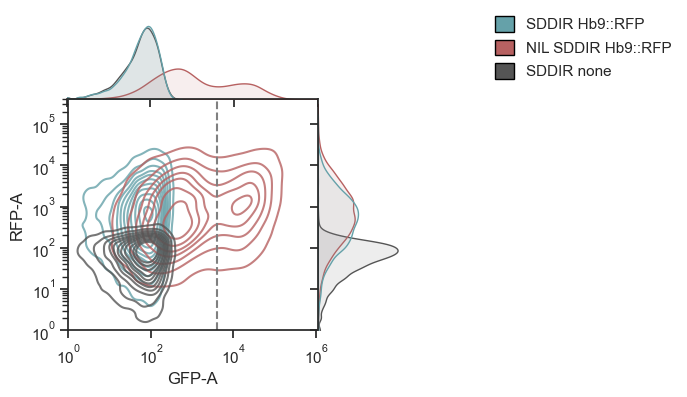

In [11]:
def jointplot(x, y, data, height=3, hue=None, hue_order=None,
              plottitle='', palette='viridis', type='scatter',
              x_gate=None, y_gate=None,
              xlim=(1, 5*10**7), ylim=(1, 5*10**7)):

    g = sns.JointGrid(
        data=data,
        x=x,
        y=y,
        hue=hue,
        ratio=3,
        hue_order=hue_order,
        space=0,
        xlim=xlim,
        ylim=ylim,
        height=height
    )

    # Increase figure size while keeping square plot
    g.fig.set_size_inches(5, 4)

    # Plot marginal distributions
    g = g.plot_marginals(
        sns.kdeplot,
        fill=True,
        alpha=0.1,
        common_norm=False,
        log_scale=True,
        palette=palette
    )

    ax = g.ax_joint

    # Make joint plot square
    ax.set_aspect('equal', adjustable='box')

    # Remove small ticks from right marginal y-axis
    g.ax_marg_y.tick_params(
        axis='y',
        which='minor',
        length=0
    )

    # Make joint plot square
    ax.set_aspect('equal', adjustable='box')

    # Main plot
    if 'scatter' in type:
        g.plot_joint(
            sns.scatterplot,
            s=3,
            hue_order=hue_order,
            palette=palette
        )

    if 'contour' in type:
        g.plot_joint(
            sns.kdeplot,
            alpha=0.8,
            palette=palette,
            common_norm=True,
            levels=12
        )

    if 'filled' in type:
        for cond in hue_order:
            g.plot_joint(
                sns.kdeplot,
                data=data[data[hue] == cond],
                alpha=0.5,
                fill=True,
                palette=palette
            )

    # Add gates
    if x_gate:
        ax.axvline(
            x_gate,
            color='grey',
            linestyle='--'
        )

    if y_gate:
        ax.axhline(
            y_gate,
            color='grey',
            linestyle='--'
        )

    # Remove title
    ax.set_title('')

    from matplotlib.patches import Patch

    # Remove seaborn legend
    if ax.get_legend() is not None:
        ax.get_legend().remove()

    # Custom legend with filled boxes
    legend_handles = [
        Patch(
            facecolor=palette[cond],
            edgecolor='black',
            linewidth=1,
            label=cond
        )
        for cond in hue_order
    ]

    ax.legend(
        handles=legend_handles,
        title='',
        loc='upper left',
        bbox_to_anchor=(0.98, 1),
        bbox_transform=g.fig.transFigure,
        frameon=False,
        handlelength=1.2,
        handleheight=1.2
    )

    # Leave space for legend without compressing plot
    plt.subplots_adjust(
        left=0.15,
        right=0.82,
        top=0.95,
        bottom=0.18
    )

lim_dict = {'GFP-A':[1,1*10**6],
            'RFP-A':[1,4*10**5]}

reporter_order = ['Hb9::RFP','Syn::RFP']
ycat_order = ['RFP-A','RFP-A']

reporter = 'Hb9::RFP'
y = 'RFP-A'
condition2_order = ['SDDIR ' + reporter,'NIL SDDIR ' + reporter,'SDDIR none']
palette = {condition2_order[0]:"#65a1a9",
        condition2_order[1]:"#b76161",
        condition2_order[2]:"#555555"}    

x= 'GFP-A'
slice = plot_df[(plot_df.condition2.isin(condition2_order))]
jointplot(x,y,slice.sample(20000),height=3,hue='condition2',hue_order=condition2_order,
                plottitle=reporter,palette=palette,type='contour',x_gate=iMN_gate,y_gate=None,xlim=lim_dict[x],ylim=lim_dict[y])

plottitle = f'Figure_S12B_contour.svg'
plt.savefig(rd.outfile(outputdir/plottitle),bbox_inches='tight')